In [2]:
# STEP 0 : IMPORT LIBRARY
import numpy as np
import random
import math

from math import ceil
from math import gcd
from fractions import Fraction

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

from qiskit.visualization import plot_histogram

| Library      | Fungsi             |
| ------------ | ------------------ |
| numpy        | operasi numerik    |
| math         | log dan gcd        |
| Fraction     | continued fraction |
| AerSimulator | simulator quantum  |


In [3]:
# STEP 1 : INPUT N

N = 15

print("Bilangan yang akan difaktorkan:", N)

Bilangan yang akan difaktorkan: 15


Shor memfaktorkan

𝑁=𝑝×𝑞

In [4]:
# STEP 2 : PILIH NILAI a

def choose_a(N):

    while True:

        a = random.randint(2, N-1)

        if gcd(a, N) == 1:

            return a

a = choose_a(N)

print("Nilai a =", a)

Nilai a = 14


In [5]:
# STEP 3 : MENENTUKAN JUMLAH QUBIT

n = math.ceil(math.log2(N))

phase_qubits = 2 * n
work_qubits = n

print("phase register :", phase_qubits)
print("work register :", work_qubits)

phase register : 8
work register : 4


In [6]:
# STEP 4 : MEMBUAT CIRCUIT

total_qubits = phase_qubits + work_qubits

qc = QuantumCircuit(total_qubits, phase_qubits)

print(qc)

      
 q_0: 
      
 q_1: 
      
 q_2: 
      
 q_3: 
      
 q_4: 
      
 q_5: 
      
 q_6: 
      
 q_7: 
      
 q_8: 
      
 q_9: 
      
q_10: 
      
q_11: 
      
 c: 8/
      


In [7]:
# STEP 5 : SUPERPOSITION

for q in range(phase_qubits):

    qc.h(q)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=12, num_clbits=0, params=[]), qubits=(<Qubit register=(12, "q"), index=0>, <Qubit register=(12, "q"), index=1>, <Qubit register=(12, "q"), index=2>, <Qubit register=(12, "q"), index=3>, <Qubit register=(12, "q"), index=4>, <Qubit register=(12, "q"), index=5>, <Qubit register=(12, "q"), index=6>, <Qubit register=(12, "q"), index=7>, <Qubit register=(12, "q"), index=8>, <Qubit register=(12, "q"), index=9>, <Qubit register=(12, "q"), index=10>, <Qubit register=(12, "q"), index=11>), clbits=())

In [8]:
# STEP 6 : INISIALISASI WORK REGISTER

qc.x(phase_qubits)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=12, num_clbits=0, params=[]), qubits=(<Qubit register=(12, "q"), index=0>, <Qubit register=(12, "q"), index=1>, <Qubit register=(12, "q"), index=2>, <Qubit register=(12, "q"), index=3>, <Qubit register=(12, "q"), index=4>, <Qubit register=(12, "q"), index=5>, <Qubit register=(12, "q"), index=6>, <Qubit register=(12, "q"), index=7>, <Qubit register=(12, "q"), index=8>, <Qubit register=(12, "q"), index=9>, <Qubit register=(12, "q"), index=10>, <Qubit register=(12, "q"), index=11>), clbits=())

In [9]:
# STEP 7 : MODULAR MULTIPLICATION GATE

def modular_multiplication(a, N, n):

    qc = QuantumCircuit(n)

    for i in range(n-1):

        qc.cx(i, i+1)

    return qc.to_gate(label=f"{a} mod {N}")

In [10]:
# STEP 8 : MODULAR EXPONENTIATION

def modular_exponentiation(qc, a, N, phase_qubits, work_qubits):

    n = work_qubits

    for q in range(phase_qubits):

        exponent = 2**q

        value = pow(a, exponent, N)

        gate = modular_multiplication(value, N, n)

        controlled_gate = gate.control()

        control = q

        targets = list(range(phase_qubits, phase_qubits+n))

        qc.append(controlled_gate, [control] + targets)

    return qc


qc = modular_exponentiation(qc, a, N, phase_qubits, work_qubits)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=12, num_clbits=0, params=[]), qubits=(<Qubit register=(12, "q"), index=0>, <Qubit register=(12, "q"), index=1>, <Qubit register=(12, "q"), index=2>, <Qubit register=(12, "q"), index=3>, <Qubit register=(12, "q"), index=4>, <Qubit register=(12, "q"), index=5>, <Qubit register=(12, "q"), index=6>, <Qubit register=(12, "q"), index=7>, <Qubit register=(12, "q"), index=8>, <Qubit register=(12, "q"), index=9>, <Qubit register=(12, "q"), index=10>, <Qubit register=(12, "q"), index=11>), clbits=())

In [11]:
# STEP 9 : INVERSE QFT

iqft = QFT(
    num_qubits=phase_qubits,
    inverse=True
)

qc.append(iqft, range(phase_qubits))

qc.barrier()

/tmp/ipykernel_591991/113661237.py:3: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=12, num_clbits=0, params=[]), qubits=(<Qubit register=(12, "q"), index=0>, <Qubit register=(12, "q"), index=1>, <Qubit register=(12, "q"), index=2>, <Qubit register=(12, "q"), index=3>, <Qubit register=(12, "q"), index=4>, <Qubit register=(12, "q"), index=5>, <Qubit register=(12, "q"), index=6>, <Qubit register=(12, "q"), index=7>, <Qubit register=(12, "q"), index=8>, <Qubit register=(12, "q"), index=9>, <Qubit register=(12, "q"), index=10>, <Qubit register=(12, "q"), index=11>), clbits=())

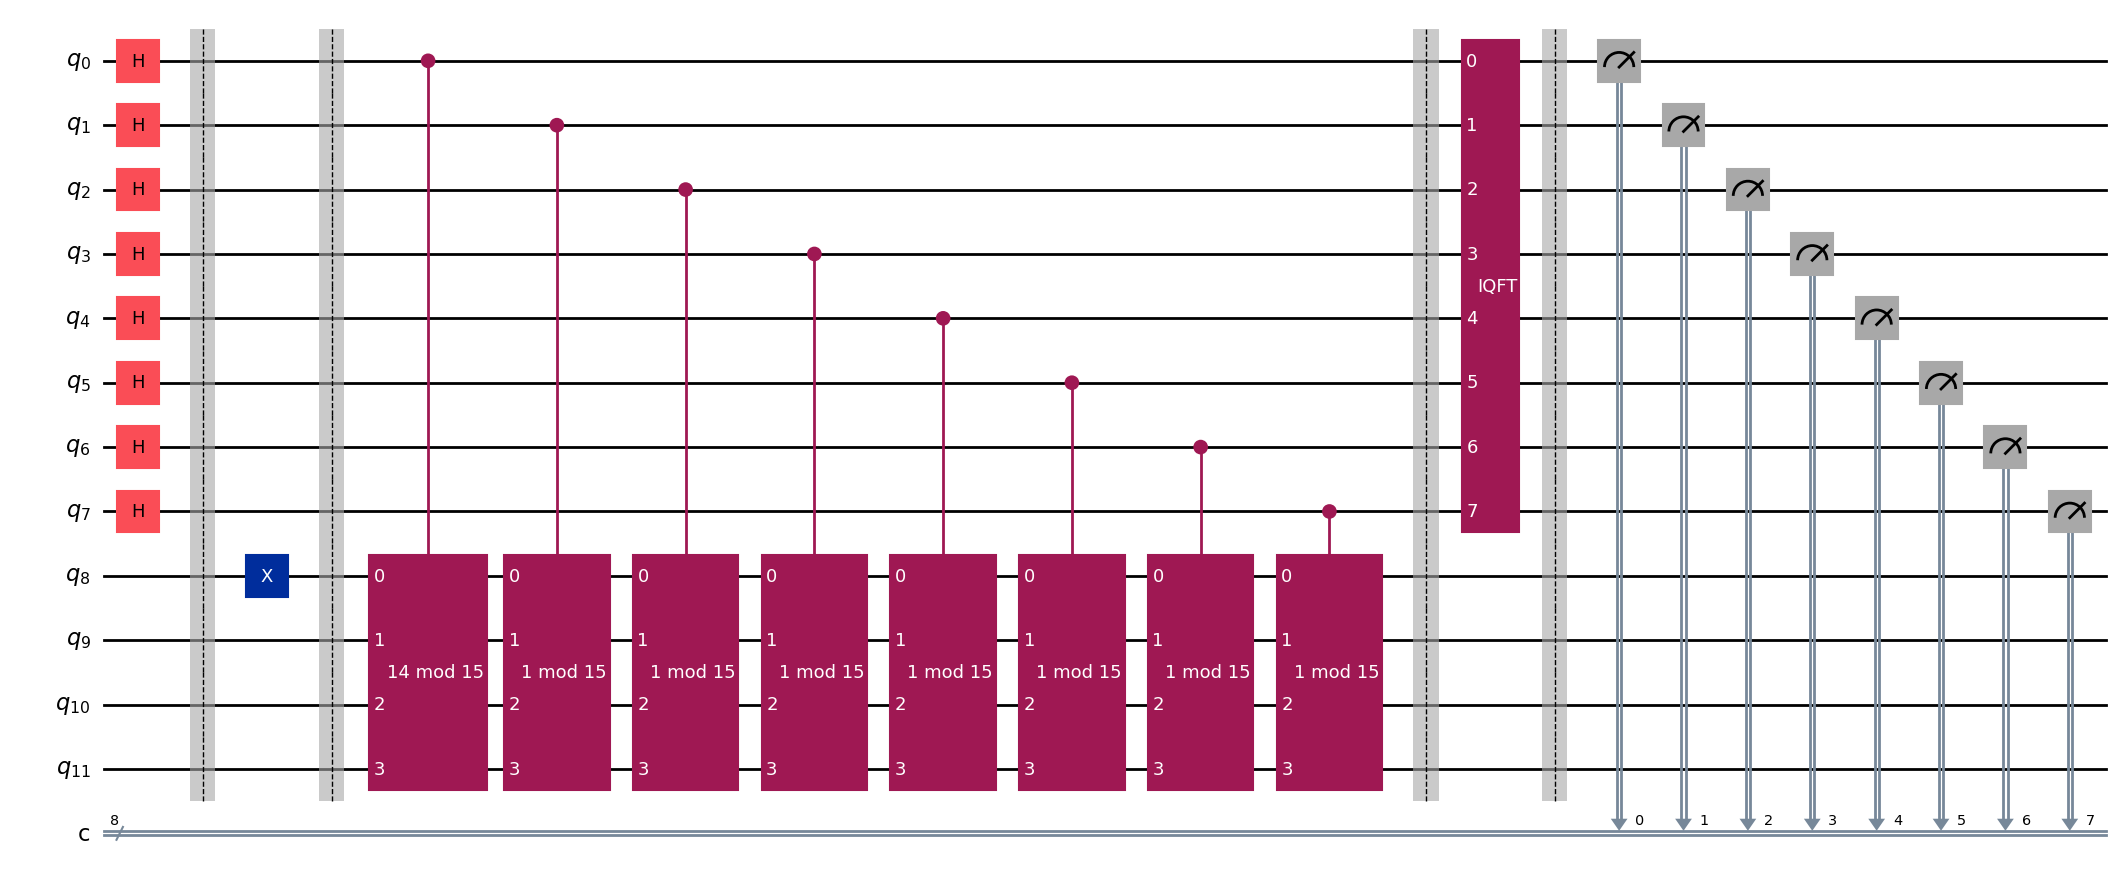

In [12]:
# STEP 10 : MEASUREMENT

qc.measure(range(phase_qubits), range(phase_qubits))

qc.draw("mpl", fold=120)

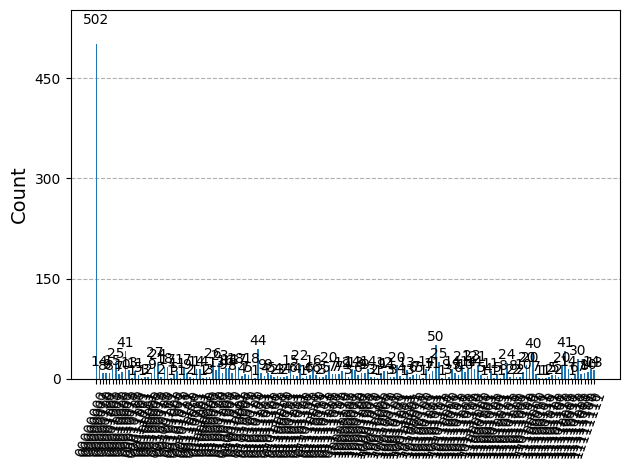

In [13]:
# STEP 11 : RUN SIMULATOR

simulator = AerSimulator()

compiled = transpile(qc, simulator)

result = simulator.run(compiled, shots=2048).result()

counts = result.get_counts()

plot_histogram(counts)

In [14]:
# STEP 12 : PERIOD FINDING

def find_period(measured, phase_qubits):

    decimal = int(measured, 2) / (2**phase_qubits)

    frac = Fraction(decimal).limit_denominator(N)

    return frac.denominator


measured_value = max(counts, key=counts.get)

r = find_period(measured_value, phase_qubits)

print("Period r =", r)

Period r = 1


In [15]:
# STEP 10 : simulasi

sim = AerSimulator()

compiled = transpile(qc, sim)

result = sim.run(compiled, shots=4096).result()

counts = result.get_counts()

print(counts)

{'11000011': 1, '10100000': 2, '11101101': 1, '00101110': 1, '11011101': 1, '11110011': 1, '11000110': 1, '10010100': 2, '00011001': 5, '11011001': 4, '00111001': 1, '11100101': 2, '10000000': 3, '11010010': 1, '00110001': 1, '10101110': 8, '11101011': 5, '01111011': 13, '11001011': 20, '10101000': 2, '00001011': 1, '01111100': 14, '01001011': 29, '00000001': 26, '11001000': 1, '01100111': 9, '10001110': 1, '11101110': 38, '01011110': 15, '10010001': 31, '10101001': 28, '10010111': 9, '10010010': 12, '10111001': 1, '11011100': 38, '11110111': 58, '10101100': 2, '11101100': 14, '01110011': 5, '00100011': 1, '11011111': 71, '01010001': 12, '00100010': 54, '00101011': 33, '01110111': 30, '00111011': 1, '10100101': 37, '11010101': 40, '11110000': 21, '10000100': 21, '01000101': 17, '00000100': 24, '00100111': 2, '11011110': 56, '01010011': 53, '00000000': 1078, '00100101': 17, '01000100': 26, '00101000': 5, '10110011': 23, '01010101': 113, '11011011': 25, '11111110': 31, '01000010': 46, '0

In [16]:
plot_histogram(counts)# STEP 13 : FACTOR EXTRACTION

if r % 2 == 0:

    p = gcd(pow(a, r//2) - 1, N)
    q = gcd(pow(a, r//2) + 1, N)

    print("Faktor ditemukan")

    print("p =", p)
    print("q =", q)

else:

    print("Period tidak valid, ulangi algoritma")

Period tidak valid, ulangi algoritma


In [17]:
# STEP 12 : mencari r

print("Analisis period")

for state,count in counts.items():

    decimal = int(state,2)/(2**phase_qubits)

    frac = Fraction(decimal).limit_denominator(N)

    print(state,"->",frac,"-> r =",frac.denominator)

Analisis period
11000011 -> 10/13 -> r = 13
10100000 -> 5/8 -> r = 8
11101101 -> 12/13 -> r = 13
00101110 -> 2/11 -> r = 11
11011101 -> 13/15 -> r = 15
11110011 -> 14/15 -> r = 15
11000110 -> 10/13 -> r = 13
10010100 -> 7/12 -> r = 12
00011001 -> 1/10 -> r = 10
11011001 -> 11/13 -> r = 13
00111001 -> 2/9 -> r = 9
11100101 -> 9/10 -> r = 10
10000000 -> 1/2 -> r = 2
11010010 -> 9/11 -> r = 11
00110001 -> 1/5 -> r = 5
10101110 -> 9/13 -> r = 13
11101011 -> 11/12 -> r = 12
01111011 -> 7/15 -> r = 15
11001011 -> 4/5 -> r = 5
10101000 -> 2/3 -> r = 3
00001011 -> 1/15 -> r = 15
01111100 -> 1/2 -> r = 2
01001011 -> 3/10 -> r = 10
00000001 -> 0 -> r = 1
11001000 -> 7/9 -> r = 9
01100111 -> 2/5 -> r = 5
10001110 -> 5/9 -> r = 9
11101110 -> 13/14 -> r = 14
01011110 -> 4/11 -> r = 11
10010001 -> 4/7 -> r = 7
10101001 -> 2/3 -> r = 3
10010111 -> 7/12 -> r = 12
10010010 -> 4/7 -> r = 7
10111001 -> 8/11 -> r = 11
11011100 -> 6/7 -> r = 7
11110111 -> 14/15 -> r = 15
10101100 -> 2/3 -> r = 3
11101100 -

In [18]:
# STEP 13 : factor extraction

r = frac.denominator

if r % 2 == 0:

    x = pow(a,r//2,N)

    p = gcd(x-1,N)
    q = gcd(x+1,N)

    print("Faktor ditemukan")
    print("p =",p)
    print("q =",q)

else:

    print("Period tidak valid, ulangi algoritma")

Period tidak valid, ulangi algoritma
